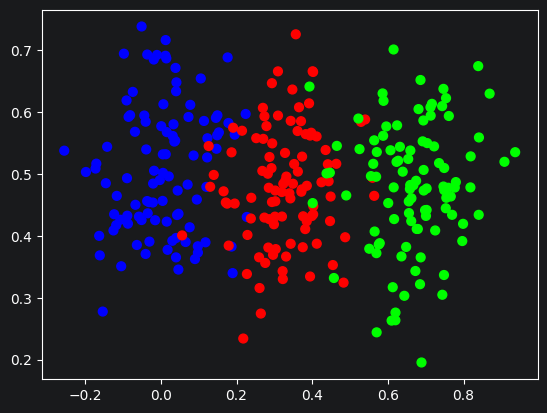

In [7]:
"""
Now that the neural network is built, able to have data
passed through it, and capable of calculating loss,
the next step is to determine how to adjust the weights
and biases s.t. we decrease loss. Finding an intelligent
way to adjust the neurons' input's weight
and biases to minimize loss is the main difficulty
of neural networks

The first option one might think of is randomly changing
the weights, checking the loss, and repeating this
until happy wih the lowest loss found.
"""

import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data

nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="brg")
plt.show()

In [2]:
"""
Use the previously created code up to this point
"""
import numpy as np
import nnfs
from nnfs.datasets import vertical_data

nnfs.init()

# Dense layer
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases


# ReLU activation
class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)


# Softmax activation
class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities


class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss


# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Number of samples in a batch
        samples = len(y_pred)
        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values -
        # only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )

        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

In [9]:
X, y = vertical_data(samples=100, classes=3)
dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalCrossentropy()

# Helper vars
lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

In [10]:
for iteration in range(10000):
    # Generate a new set of weights for iteration
    dense1.weights = .05 * np.random.randn(2, 3)
    dense1.biases = .05 * np.random.randn(1, 3)
    dense2.weights = .05 * np.random.randn(3, 3)
    dense2.biases = .05 * np.random.randn(1, 3)

    # Perform a forward pass of the training data through this layer
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    # Perform a forward pass through activation function
    # It takes the output of the second dense layer and returns loss
    loss = loss_function.calculate(activation2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # Calculate values along first axis
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions==y)

    if loss < lowest_loss:
        print("New set of weights found, iteration: ", iteration, "loss: ", loss, "accuracy: ", accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss

New set of weights found, iteration:  0 loss:  1.0993794 accuracy:  0.3333333333333333
New set of weights found, iteration:  1 loss:  1.0990648 accuracy:  0.3333333333333333
New set of weights found, iteration:  5 loss:  1.0986186 accuracy:  0.3333333333333333
New set of weights found, iteration:  12 loss:  1.0985433 accuracy:  0.3333333333333333
New set of weights found, iteration:  13 loss:  1.0968558 accuracy:  0.3333333333333333
New set of weights found, iteration:  1121 loss:  1.0963649 accuracy:  0.3333333333333333
New set of weights found, iteration:  3805 loss:  1.0962486 accuracy:  0.3333333333333333
New set of weights found, iteration:  5349 loss:  1.0957465 accuracy:  0.61


In [11]:
"""
Loss continued to drop, but accuracy did not change. This doesn't appear to be a reliable
method for minimizing loss. What if we try to just nudge in the right direction?

As in applying a fraction of these values to the parameters s.t. weights will be updated
from what currently yields the lowest loss. If an adjustment decreases loss, we will make it
the new point to adjust from. If loss increases due to the adjustment, then we will
revert to the previous point.

Let's copy some previous code and adjust it:
"""

for iteration in range(10000):
    # Generate a new set of weights for iteration
    dense1.weights += .05 * np.random.randn(2, 3)
    dense1.biases += .05 * np.random.randn(1, 3)
    dense2.weights += .05 * np.random.randn(3, 3)
    dense2.biases += .05 * np.random.randn(1, 3)

    # Perform a forward pass of the training data through this layer
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    # Perform a forward pass through activation function
    # It takes the output of the second dense layer and returns loss
    loss = loss_function.calculate(activation2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # Calculate values along first axis
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions==y)

    if loss < lowest_loss:
        print("New set of weights found, iteration: ", iteration, "loss: ", loss, "accuracy: ", accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1.weights = best_dense1_weights.copy()
        dense1.biases = best_dense1_biases.copy()
        dense2.weights = best_dense2_weights.copy()
        dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration:  7 loss:  1.0941937 accuracy:  0.5966666666666667
New set of weights found, iteration:  10 loss:  1.0938419 accuracy:  0.43333333333333335
New set of weights found, iteration:  12 loss:  1.0917957 accuracy:  0.6666666666666666
New set of weights found, iteration:  15 loss:  1.0891093 accuracy:  0.5866666666666667
New set of weights found, iteration:  17 loss:  1.0867251 accuracy:  0.3333333333333333
New set of weights found, iteration:  20 loss:  1.0842066 accuracy:  0.6133333333333333
New set of weights found, iteration:  21 loss:  1.0830961 accuracy:  0.62
New set of weights found, iteration:  31 loss:  1.078066 accuracy:  0.3333333333333333
New set of weights found, iteration:  39 loss:  1.0736749 accuracy:  0.35
New set of weights found, iteration:  40 loss:  1.070854 accuracy:  0.5633333333333334
New set of weights found, iteration:  41 loss:  1.0630383 accuracy:  0.3333333333333333
New set of weights found, iteration:  43 loss:  1.0623856 accu

In [12]:
"""
If we try this with the spiral dataset we will see that there is almost no progress here. Loss
decreases slightly and accuracy is barely above the initial value. Later we'll learn that the
most probably reason for this is called a local minimum of loss. We need to inch towards a
global minimum and approach this more intelligently.
"""